In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.datasets import make_regression
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
np.set_printoptions(suppress=True)

Zadanie 1 — Pierwszy model liniowy
Dopasuj prosty model regresji liniowej do danych syntetycznych i sprawdź, czego się nauczył.
Wygeneruj syntetyczne dane z jedną cechą i dodanym szumem.
Utwórz model regresji liniowej i dopasuj go do danych.
Odczytaj wyznaczone współczynniki modelu: nachylenie i wyraz wolny.
Narysuj punkty danych oraz dopasowaną prostą na jednym wykresie.


X_train: Dane wejściowe (cechy) używane wyłącznie do nauki modelu. 

y_train: Prawidłowe odpowiedzi (wyniki) przypisane do danych z X_train. Model patrzy na nie podczas nauki.

X_test: Dane wejściowe odłożone na bok. Model ich nie widzi podczas nauki. Użyjesz ich później do sprawdzenia, jak radzi sobie z nowymi danymi.

y_test: Prawidłowe odpowiedzi dla zbioru testowego. Służą jako "klucz odpowiedzi" do oceny skuteczności modelu.



In [2]:
#tworzymy rozklad na podstawie gausa wiec nie ma tutaj wartosci odstajacych 
X, y = make_regression(n_samples=200, n_features=1, noise=5, random_state=42)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state =42)


In [4]:
model = LinearRegression()

In [5]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


metoda najmniejszych kwadratow - Model szuka takiej linii, która będzie leżała najbliżej wszystkich punktów ze zbioru treningowego.
1. Mierzy błędy: sprawdza pionową odległość każdego punktu od linii.² 
2. Podnosi do kwadratu: usuwa minusy i mocniej karze duże błędy. 
3. Minimalizuje sumę: szuka najniższego możliwego wyniku tej sumy. 
4. Zapisuje parametry: wypluwa tylko coef_ i intercept_

In [6]:
model.coef_
#wspolczynik kierunkowy - o ile zmieni sie zmienna przewidywana jesli zmienna wejsciowa wzrosnei o jedna jednostke - ceteris paribus

array([87.43086589])

In [7]:
model.intercept_
#wyraz wolny - punkt tam gdzie linia przecina os y

np.float64(0.6115255461698084)

In [8]:
#pytania ktore model na przewidziec - czyli mamy coef * x test + intercept = odp
X_test

array([[ 0.78182287],
       [ 0.29698467],
       [-1.42474819],
       [ 0.06856297],
       [-0.91942423],
       [ 0.79103195],
       [-0.3011037 ],
       [-0.29169375],
       [-1.95967012],
       [-1.24573878],
       [ 0.24196227],
       [-0.46063877],
       [-0.75373616],
       [ 0.31424733],
       [-1.06230371],
       [-2.6197451 ],
       [-0.56629773],
       [ 0.36163603],
       [ 0.18463386],
       [ 0.47383292],
       [ 0.49671415],
       [ 0.08704707],
       [ 2.19045563],
       [-0.07444592],
       [-0.68002472],
       [ 0.29612028],
       [ 1.54993441],
       [ 0.36139561],
       [-0.64511975],
       [ 1.15859558],
       [ 0.65655361],
       [-0.97468167],
       [ 1.14282281],
       [-1.19620662],
       [-0.23413696],
       [ 1.05712223],
       [-0.70205309],
       [-0.54438272],
       [-0.88951443],
       [-1.72491783]])

In [9]:

#prawdziwe odp 
y_test

array([  72.44934898,   21.83595094, -123.21704658,    7.03464442,
        -74.89603479,   73.25640458,  -18.11151878,  -24.94966913,
       -169.72580957, -107.7354735 ,   27.88352479,  -38.82637019,
        -75.18143802,   20.06737279,  -90.40812125, -226.61356748,
        -45.66637261,   32.02151553,   15.95830014,   43.60395797,
         47.94259802,   -1.84960955,  201.03683572,   -1.78596924,
        -59.31527457,   28.73948077,  133.60016237,   33.7327548 ,
        -44.86108544,  101.09739655,   66.90408068,  -79.51388737,
        106.29281095, -111.45291225,  -23.56206798,   84.68792097,
        -59.7861784 ,  -49.83533336,  -87.60713335, -150.17816496])

In [10]:
#wartosci ktore przewidzial model
y_pred = model.predict(X_test)
y_pred

array([  68.9669762 ,   26.57715268, -123.95544205,    6.6060458 ,
        -79.77453137,   69.77213362,  -25.71423128,  -24.89151157,
       -170.72413024, -108.30449455,   21.76649646,  -39.66252106,
        -65.28827996,   28.08644194,  -92.26660798, -228.43505731,
        -48.9003753 ,   32.22967635,   16.75422367,   42.03914811,
         44.03967404,    8.2221261 ,  192.1249576 ,   -5.89734533,
        -58.84362469,   26.50157778,  136.12363265,   32.20865626,
        -55.7918532 ,  101.90854023,   58.01457605,  -84.60573685,
        100.52951378, -103.97385538,  -19.85927134,   93.03663713,
        -60.76958435,  -46.98432743,  -77.15949126, -150.19953414])

In [11]:
#resztki modelu blad modelu
residuals = y_test - y_pred
residuals

array([  3.48237278,  -4.74120174,   0.73839547,   0.42859862,
         4.87849658,   3.48427096,   7.6027125 ,  -0.05815756,
         0.99832067,   0.56902104,   6.11702833,   0.83615087,
        -9.89315806,  -8.01906915,   1.85848673,   1.82148983,
         3.2340027 ,  -0.20816082,  -0.79592353,   1.56480986,
         3.90292397, -10.07173564,   8.91187811,   4.11137609,
        -0.47164989,   2.23790299,  -2.52347028,   1.52409854,
        10.93076776,  -0.81114368,   8.88950463,   5.09184947,
         5.76329718,  -7.47905687,  -3.70279664,  -8.34871617,
         0.98340595,  -2.85100593, -10.44764209,   0.02136917])

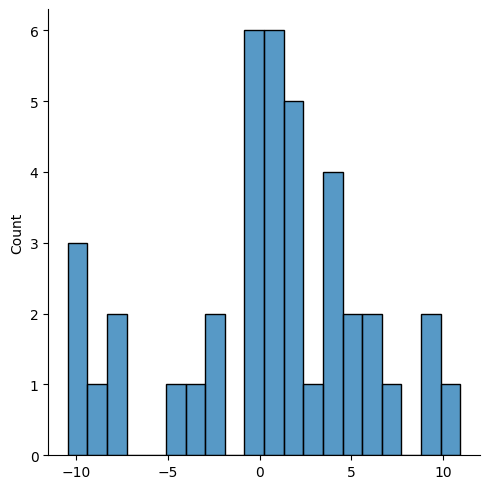

In [12]:
sns.displot(residuals, bins=20) # model b dobry

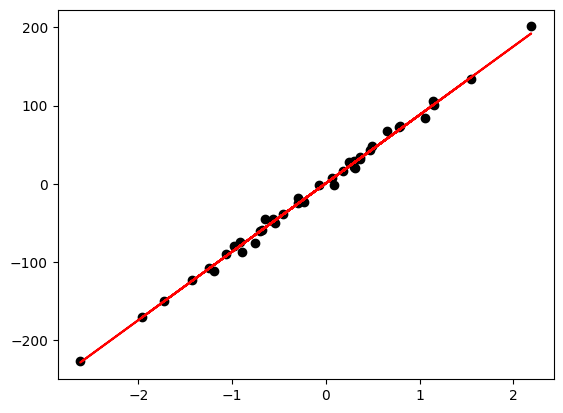

In [13]:
plt.scatter(X_test, y_test, color='black')
plt.plot(X_test, y_pred, color='red')

Zadanie 2 — Predykcja i ocena modelu
Sprawdź, jak dobrze model przewiduje na danych, których nie widział.
Podziel dane na część treningową i testową.
Dopasuj model wyłącznie na danych treningowych.
Wykonaj predykcję na danych testowych.
Policz podstawowe metryki jakości na zbiorze testowym i krótko oceń dopasowanie.


In [14]:
mae = mean_absolute_error(y_test,y_pred)
mae


4.010135471872961

In [15]:
mse = mean_squared_error(y_test,y_pred)
mse

27.346865876293883

In [16]:
rmse = np.sqrt(mse)
rmse

np.float64(5.229423092110054)

MAE (Mean Absolute Error): Średnia arytmetyczna bezwzględnych różnic między wartościami przewidywanymi a rzeczywistymi. Traktuje wszystkie błędy równorzędnie.

MSE (Mean Squared Error): Średnia kwadratów tych różnic. Przez potęgowanie mocno uwypukla (karze) duże błędy i wartości odstające (tzw. outliery).

RMSE (Root Mean Squared Error): Pierwiastek kwadratowy z MSE. Działa podobnie do MSE, ale zwraca wynik w tych samych jednostkach co badana zmienna, co ułatwia interpretację.

Najlepsze wartości Wartość idealna: 
0 Co oznacza: Model jest perfekcyjny. Każda prognoza idealnie pokrywa się z wartością rzeczywistą (\(y_{pred} = y_{real}\)). W praktyce na realnych danych wynik 0 prawie nigdy się nie zdarza i zazwyczaj oznacza błąd w kodzie lub tzw. wyciek danych (data leakage).Najgorsze wartości

Wartość najgorsza: \(\infty \) (Nieskończoność) Co oznacza: Te błędy nie mają górnego limitu. Im bardziej model się myli, tym wyższe są wartości. Wartość MSE rośnie najszybciej, ponieważ duże błędy są podnoszone do kwadratu.

In [17]:
# bledy sa na git poziomie 

Zadanie 3 — Porównanie metryk błędu
Napisz funkcję, która liczy kilka metryk i pokaż, jak reagują na wartość odstającą.
W funkcji policz kilka miar błędu (m.in. średni błąd kwadratowy, jego pierwiastek, średni błąd bezwzględny oraz współczynnik determinacji).
Przetestuj funkcję na danych bez wartości odstających.
Dodaj do danych jedną silnie odstającą obserwację i policz metryki ponownie.
Porównaj, które metryki mocniej zareagowały na outlier, i wyciągnij wniosek.


In [18]:
#wartosci normalne

In [19]:
def calculate_functions(y_test, y_pred):
    mse = mean_squared_error(y_test,y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test,y_pred)
    r2 = r2_score(y_test, y_pred)

    return f" mse {mse}, rmse {rmse}, mae {mae}, r2 {r2}"
calculate_functions(y_test, y_pred)

' mse 27.346865876293883, rmse 5.229423092110054, mae 4.010135471872961, r2 0.9963016153862634'

In [20]:
#wrzucamy jednego outlinera do odpowiedzi i zobaczymy jak model zareaguje 
y_test_outliner = y_test.copy()
y_test_outliner[0] = 800

y_test_outliner

array([ 800.        ,   21.83595094, -123.21704658,    7.03464442,
        -74.89603479,   73.25640458,  -18.11151878,  -24.94966913,
       -169.72580957, -107.7354735 ,   27.88352479,  -38.82637019,
        -75.18143802,   20.06737279,  -90.40812125, -226.61356748,
        -45.66637261,   32.02151553,   15.95830014,   43.60395797,
         47.94259802,   -1.84960955,  201.03683572,   -1.78596924,
        -59.31527457,   28.73948077,  133.60016237,   33.7327548 ,
        -44.86108544,  101.09739655,   66.90408068,  -79.51388737,
        106.29281095, -111.45291225,  -23.56206798,   84.68792097,
        -59.7861784 ,  -49.83533336,  -87.60713335, -150.17816496])

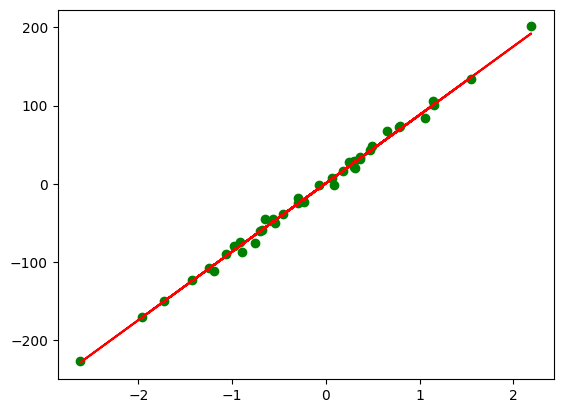

In [21]:
plt.scatter(X_test, y_test, color = 'green')
plt.plot(X_test, y_pred, color = 'red')

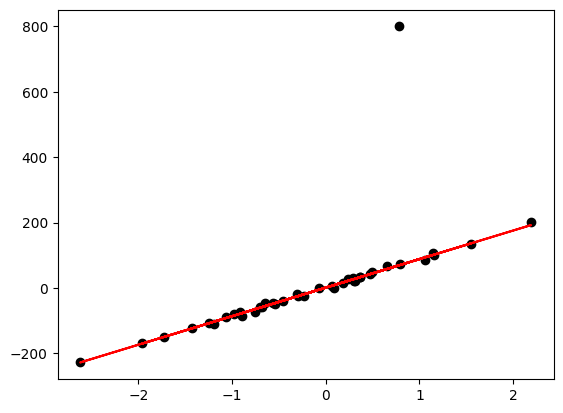

In [22]:
plt.scatter(X_test, y_test_outliner, color='black')
plt.plot(X_test, y_pred, color='red')

In [23]:
residuals3 = y_test_outliner - y_pred
residuals3


array([731.0330238 ,  -4.74120174,   0.73839547,   0.42859862,
         4.87849658,   3.48427096,   7.6027125 ,  -0.05815756,
         0.99832067,   0.56902104,   6.11702833,   0.83615087,
        -9.89315806,  -8.01906915,   1.85848673,   1.82148983,
         3.2340027 ,  -0.20816082,  -0.79592353,   1.56480986,
         3.90292397, -10.07173564,   8.91187811,   4.11137609,
        -0.47164989,   2.23790299,  -2.52347028,   1.52409854,
        10.93076776,  -0.81114368,   8.88950463,   5.09184947,
         5.76329718,  -7.47905687,  -3.70279664,  -8.34871617,
         0.98340595,  -2.85100593, -10.44764209,   0.02136917])

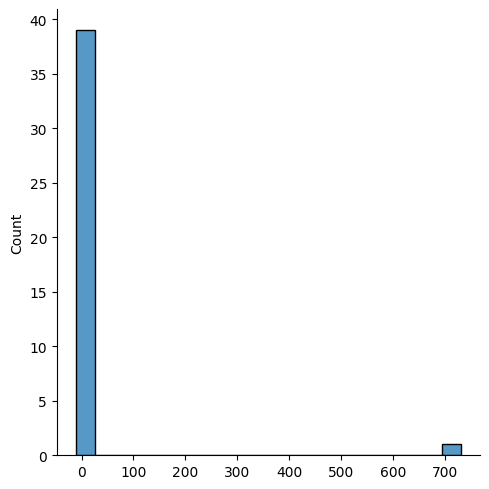

In [24]:
sns.displot(residuals3, bins=20) 

In [25]:
# z outlinerem

calculate_functions(y_test_outliner, y_pred)

' mse 13387.275740123077, rmse 115.7033955427544, mae 22.198901747402967, r2 0.428617508207757'

#najbardziej zareagowalo mse bo bylo podniesione do kwadratu 
MSE (Błąd średniokwadratowy): Oblicza średnią z kwadratów różnic między wartościami rzeczywistymi a przewidywanymi. Przez potęgowanie błędów jest ekstremalnie wrażliwy na wartości odstające i natychmiastowo na nie reaguje.

RMSE (Pierwiastek błędu średniokwadratowego): Stanowi pierwiastek kwadratowy z MSE, dzięki czemu wyraża błąd w tych samych jednostkach co zmienna docelowa. Zachowuje wysoką wrażliwość na anomalie, ale jest znacznie łatwiejszy do intuicyjnej interpretacji.

MAE (Średni błąd bezwzględny): Mierzy średnią z absolutnych (bezwzględnych) różnic między predykcją a rzeczywistością bez podnoszenia ich do potęgi. Traktuje wszystkie pomyłki liniowo, przez co pozostaje stabilny i odporny na pojedyncze, gigantyczne anomalie.\

(R^2) (Współczynnik determinacji): Określa, jaki procent zmienności zmiennej zależnej został wyjaśniony przez dany model matematyczny. Przyjmuje wartości zazwyczaj od 0 do 1, gdzie wynik bliski jedności oznacza niemal perfekcyjne dopasowanie.

Zadanie 4 — Wykrywanie współliniowości
Sprawdź, czy cechy nie powielają tej samej informacji.
Przygotuj dane, w których jedna cecha jest niemal liniową kombinacją innej.
Napisz funkcję liczącą miarę współliniowości dla każdej cechy.
Wypisz otrzymane wartości dla wszystkich cech.
Wskaż cechy o wysokiej współliniowości jako kandydatów do usunięcia.


In [26]:
X_1, y_1 = make_regression(n_samples=200, n_features=4, noise=5, random_state=42)
X_1[:,1] = X_1[:,0] * 2

In [27]:
X_1_train, X_1_test, y_1_train, y_1_test = train_test_split(X_1, y_1, test_size=0.2, random_state=42)

In [28]:
X_1_train

array([[-1.43014138, -2.86028276, -0.25256815, -1.24778318],
       [ 0.58831721,  1.17663441,  2.13303337, -1.9520878 ],
       [ 0.48247242,  0.96494483,  0.62566735, -0.85715756],
       [ 0.70030988,  1.40061976,  0.4933179 ,  0.18483612],
       [-0.51827022, -1.03654044, -0.21967189,  0.35711257],
       [ 0.0125924 ,  0.0251848 ,  0.69014399, -0.40122047],
       [ 0.75193303,  1.50386607, -0.03471177, -1.16867804],
       [-0.20304539, -0.40609077, -2.4716445 , -0.79689526],
       [ 1.52955032,  3.05910064,  0.05572491,  1.09419152],
       [ 0.18463386,  0.36926772,  0.22745993,  1.30714275],
       [-1.29507877, -2.59015754,  0.82317058,  0.07331797],
       [-0.32602353, -0.65204706,  0.28977486,  2.0754008 ],
       [ 0.8219025 ,  1.64380501, -0.03582604,  1.56464366],
       [ 0.34758171,  0.69516341,  0.17086544, -0.18398334],
       [ 1.05315285,  2.10630571,  0.27157884, -1.27674858],
       [ 0.61058575,  1.22117149,  0.177701  , -1.33534436],
       [ 0.56296924,  1.

In [29]:
df = pd.DataFrame(X_1_train, columns=['Cecha_1', 'Cecha_2*', 'Cecha_3', 'Cecha_4'])
df

,Cecha_1,Cecha_2*,Cecha_3,Cecha_4
0,-1.430141,-2.860283,-0.252568,-1.247783
1,0.588317,1.176634,2.133033,-1.952088
2,0.482472,0.964945,0.625667,-0.857158
3,0.700310,1.400620,0.493318,0.184836
4,-0.518270,-1.036540,-0.219672,0.357113
...,...,...,...,...
155,0.462103,0.924207,1.163164,0.010233
156,-0.591571,-1.183143,-0.020902,0.117327
157,-1.244655,-2.489309,0.413435,1.876796
158,-0.820682,-1.641365,-0.974682,0.787085


VIF sprawdza, czy zmienne niezależne w Twoim modelu nie są zbyt mocno ze sobą powiązane (czy nie dublują tej samej informacji).

In [30]:
import statsmodels.api as sm
from statsmodels.api import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

def check_vif(df):
    #wyraz wolny musi byc zeby obliczenia byly prawidlowe
    df_z_wyraz_wolny = add_constant(df)
    #sprawdzenie ile kolumn mamy
    l_kolumn = df_z_wyraz_wolny.shape[1]
    for i in range(l_kolumn):
        aktualny_vif = variance_inflation_factor(df_z_wyraz_wolny.values, i)
        print(f" wyniki vif {i} : {aktualny_vif}")
    

    

check_vif(df)


 wyniki vif 0 : 1.0086566958338687
 wyniki vif 1 : inf
 wyniki vif 2 : inf
 wyniki vif 3 : 1.0095018281565993
 wyniki vif 4 : 1.009217611751876


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


#mamy wspolkniniowosc w 1 i 2 cesze bo mamy nieskonczonosc 

takie same liczby tylko pomnozone razy dwa maja taka sama korelacje, wiec wsp. determinacji wychodzi 1/0 to daje nieskonczonosc.

In [31]:
#R 2(Współczynnik determinacji) to najważniejsza metryka, która mówi, jak dobrze Twój model pasuje do danych.
#wartosci 1 - oznaczaja ze cechy sa niezalezne , im wyzej tym gorzej

zadanie 5 — Regresja wielu cech
Zbuduj model na kilku cechach i sprawdź, które są najważniejsze.
Wygeneruj dane z kilkoma cechami i szumem.
Podziel dane i dopasuj model na części treningowej.
Porównaj wielkość współczynników przy poszczególnych cechach, aby ocenić ich wpływ.
Oceń jakość modelu na zbiorze testowym


In [32]:
X_2, y_2 = make_regression(n_samples=400, n_features=4, noise=5, random_state=42)
X_2_train, X_2_test, y_2_train, y_2_test= train_test_split(X_2, y_2, test_size = 0.2, random_state=42)
#liczy poczatkowe wygenrowane przez kompa
X_2_train

array([[-0.15852957, -0.02730454, -0.93326796,  1.1965715 ],
       [-0.55358824,  0.56898308,  1.62839662,  1.67770081],
       [ 0.22378795, -0.0164229 ,  1.18839327, -0.5176113 ],
       ...,
       [ 0.87245733,  0.65020118, -0.09917586, -1.2803044 ],
       [ 0.8496021 ,  0.35701549, -0.6929096 , -0.58936476],
       [-0.42688107, -1.01210438, -1.65485667, -0.1580079 ]],
      shape=(320, 4))

In [33]:
#wynik tych liczb ktore zostaly pomnozone przez wage + szum
y_2_train

array([  13.97299709,  252.01743943,   62.27657675,  -53.69895756,
       -101.35962115,  120.54510655,  115.92414867,   90.95643109,
        -38.20399059,  -67.00033263,   39.7299455 ,  -78.54484753,
        145.19662095,   34.9160934 ,   15.61897945,  -51.34499224,
       -234.23998118,   26.99571233,  282.89963784,  155.43029631,
        -95.55605161,  183.32793414,  -51.48336356,  202.7942569 ,
         30.29097667,  -43.07730624,   -5.6670705 , -191.91057746,
         50.93807116,  103.39538611, -132.15789801, -177.39140765,
        -83.89727266,  141.52589394,  -15.74813214, -115.29275328,
        121.26280592, -183.37137711, -244.12612332,  121.62126524,
         -0.99019032,  126.5329726 , -175.28121164,  -72.39101531,
        -33.09485938,  203.41417318, -154.76684745,  -12.16998667,
       -195.39479685,   98.78180089,   78.23773408,  -39.73069711,
         37.27543585,  -36.10339538, -193.77415591,   30.64219801,
         78.06829112,  212.67123254,  190.90391967,  163.16251

In [34]:
model = LinearRegression()
model.fit(X_2_train, y_2_train)
model.coef_
#coef Określa siłę i kierunek wpływu zmiennej wejściowej (cechy) na wynik końcowy. - 
#Jeśli zmienna \(X\) wzrośnie o dokładnie 1 jednostkę, to wynik \(Y\) zmieni się średnio o wartość tego współczynnika
#Gdy coef jest dodatni (np. 5.5): Jeśli zmienna wzrośnie o 1, wynik wzrośnie o 5.5.Gdy coef jest ujemny (np. -12.0): 
#Jeśli zmienna wzrośnie o 1, wynik zmaleje o 12.
#najwiekszy wplyw ma cecha 4. 

array([46.10757843,  5.39259721, 78.80112401, 80.95350517])

In [35]:
y_pred_2 = model.predict(X_2_test)
y_pred_2, X_2_test


(array([ 207.40767142,   16.66103425,    7.31694544,  143.74022576,
        -166.22879419,  -37.53543248,   52.8323203 ,   55.05284007,
          80.24485841,   -3.30674469,  114.15388576,  166.77186841,
        -123.43385407,  -79.90410173,  172.30216689,  251.33017761,
          51.59667799,   -2.25476506,   -9.19661647,  275.22164334,
        -122.772343  ,  227.52826461,    9.13219759,   69.49039536,
         138.969215  , -225.44842193,  -15.10209756,   43.77969815,
        -114.24668393,   85.00427452,  167.85526922,  247.57995024,
           3.93334361,   -1.33019758, -112.93517461, -121.48963467,
          35.34983016,   52.75610492,   84.66622155,    6.95967715,
        -152.99685963,   62.96215122,  156.78580544,   32.80022999,
          71.10923677,  292.59252789, -104.26711745, -127.01088288,
         102.4047084 ,  -21.36180279, -117.50328409,   -5.45068739,
         -57.33612563,  -72.91282875, -144.45071412,   -8.33276517,
          -9.88557993, -123.29482209,  144.18935

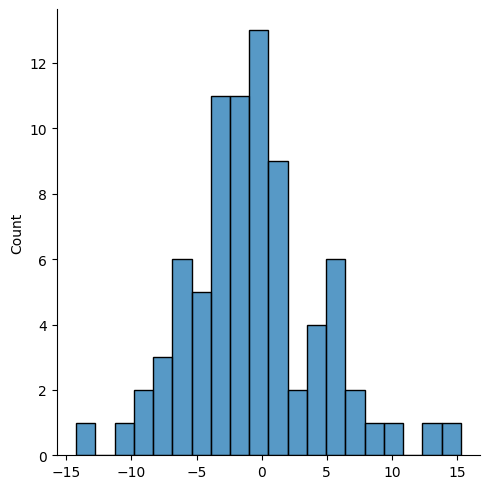

In [35]:
residuals2 = y_2_test - y_pred_2
residuals2
sns.displot(residuals2, bins=20) # model b dobry

In [36]:
y_2_test

array([ 204.20600277,   12.57439239,    8.96723484,  143.53877801,
       -169.03058358,  -46.45356056,   54.44179234,   54.13269176,
         81.97924044,   -4.30237287,  112.76423799,  172.78962738,
       -125.82978062,  -86.74864161,  162.36250981,  252.3172451 ,
         59.29749909,  -10.04908598,   -1.04567471,  279.26373437,
       -119.54228908,  233.06857882,    2.67739513,   68.66085269,
        136.8992577 , -218.28706936,  -17.98326458,   48.39036137,
       -115.15216396,   78.93255513,  163.30217733,  245.48671271,
         -1.55534954,   -9.99065485, -118.20835625, -121.89104474,
         28.48293094,   68.05016346,   85.05739148,    8.92465367,
       -152.05402481,   61.56716288,  152.95711604,   32.0746623 ,
         71.69826692,  284.57836424, -105.93526159, -132.44417821,
        103.74748058,  -23.18355404, -112.07827746,    0.62578886,
        -60.97552218,  -59.8889276 , -144.41301345,  -11.70005305,
          0.54849267, -128.4817212 ,  147.64689678,  152.64031

Text(0, 0.5, 'przewidywanie wartosci')

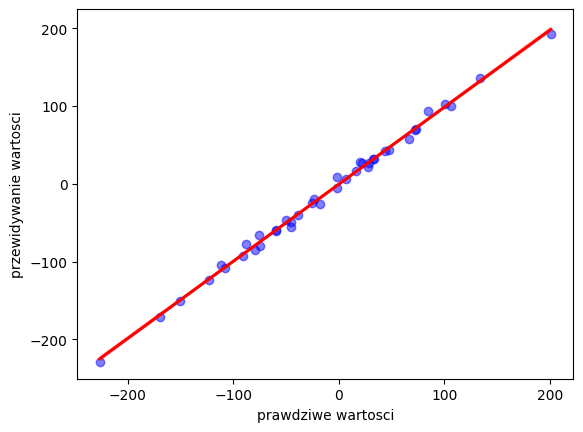

In [37]:
#wykres z linia regresji
sns.regplot(x=y_test, y=y_pred, scatter_kws={'color': 'blue', 'alpha': 0.5}, line_kws={'color': 'red'})
plt.xlabel("prawdziwe wartosci")
plt.ylabel("przewidywanie wartosci")


In [38]:
mae = mean_absolute_error(y_2_test,y_pred_2)
mse = mean_squared_error(y_2_test,y_pred_2)
rmse = np.sqrt(mse)
r2 = r2_score(y_2_test, y_pred_2)
print(f" mae {mae}, mse {mse}, rmse {rmse}, r2 {r2}")

 mae 3.9872739771037624, mse 26.584459965230497, rmse 5.15601202143968, r2 0.9979117882383153


In [39]:
#mae srednia pomylka modelu
#MSE: Bezwzględnie karze algorytm za największe pomyłki (outliery), potęgując ich wartość do kwadratu.
#RMSE: Zachowuje karę za outliery z MSE, ale sprowadza wynik z powrotem do realnej jednostki bazowej (np. różnicy w dolarach na wykresie).
#R 2: Określa ułamkowo (od 0 do 1), w ilu procentach Twój model poprawnie rozpracował zmienność danych.

Mając zbiór danych z wieloma cechami (część nieistotnych, dodanych jako szum), napisz funkcję compare_regularization(X, y), która trenuje LinearRegression, Ridge i Lasso, porównuje ich błędy testowe oraz pokazuje, które współczynniki Lasso wyzerował.


Lasso i Ridge - obie metody służą do regularyzacji, czyli zapobiegania przeuczeniu (overfittingowi) poprzez nakładanie "kary" na model za posiadanie zbyt dużych wag.

In [40]:
from sklearn.linear_model import LassoCV
from sklearn.linear_model import RidgeCV
X_3, y_3 = make_regression(n_samples=400, n_features=4, noise=5, random_state=42, n_informative=2)


In [41]:
def compare_regularization(X,y):
    X_3_train, X_3_test, y_3_train, y_3_test= train_test_split(X_3, y_3, test_size = 0.2, random_state=42)
    
    model_lr = LinearRegression()
    model_lr.fit(X_3_train, y_3_train)
    
    pred_lr = model.predict(X_3_test)
    residuals = y_3_test - pred_lr
    mse_lr = mean_squared_error(y_3_test, pred_lr)
    mae_lr = mean_absolute_error(y_3_test, pred_lr)
    rmse_lr = np.sqrt(mse_lr)
    

    model_ridge = RidgeCV(cv=5)
    model_ridge.fit(X_3_train,y_3_train)
    pred_ridge = model_ridge.predict(X_3_test)
    mse_ridge = mean_squared_error(y_3_test, pred_ridge)


    model_lasso = LassoCV(cv=5)
    model_lasso.fit(X_3_train,y_3_train)
    pred_lasso = model_lasso.predict(X_3_test)
    mse_lasso = mean_squared_error(y_3_test, pred_lasso)

    

    return f" model lr mse : {mse_lr} mae lr : {mae_lr}, rmse lr {rmse_lr}, model ridge mse: {mse_ridge}, model lasso mse: {mse_lasso}, wagi Lasso: {model_lasso.coef_}"

compare_regularization(X_3,y_3)

' model lr mse : 5131.154737676555 mae lr : 58.297519523796254, rmse lr 71.63207897078344, model ridge mse: 26.54788645405141, model lasso mse: 26.39352378252868, wagi Lasso: [45.96444006  0.05118178  0.06291911 80.7870828 ]'

# mse wyszlo dosyc spore sprawdzamy przyczyne - rmse 71 czyli model myli sie srednio o 71 jednostek. mamy skale 400 i przy 2 cechach nieinformatywnych jest to normalne

PODSUMOWANIE

model dal sie oszukac i przewidzial lr mse na 5k i rmse na 71 jednostek. potem sprawdziajac metoda lasso model pokazal dwie cechy ktore sa nieinformatywne.
    finalnie mse spadlo do 26 a rmse jakos okolo 5 czyli model jest git

Oto najkrótsze podsumowanie – oba modele chronią przed przeuczeniem (szumem), ale robią to inaczej:Lasso (Selekcjoner): Całkowicie zeruje wagi zbędnych kolumn. Działa jak filtr – wyrzuca śmieci i zostawia tylko te cechy, które naprawdę mają znaczenie.Ridge (Stabilizator): Zmniejsza wagi wszystkich kolumn, ale żadnej nie zeruje. Działa jak hamulec – nie pozwala żadnej cesie zbytnio zdominować modelu, co pomaga przy dużym VIF.

Zadanie 4 — Bias-variance na różnych stopniach wielomianu
 Napisz funkcję bias_variance_experiment(X, y, degrees), która dla różnych stopni regresji wielomianowej (np. 1, 3, 10) liczy błąd na zbiorze treningowym i testowym, a wynik przedstawia na wykresie — tak by pokazać underfitting i overfitting.

In [53]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression


#PROBKA WYTRENOWANIE RL Na takich danych
np.random.seed(42)
X_4 = np.random.uniform(-3, 3, size=(100, 1))
y_4 = 0.5 * X**3 + X + 2 + np.random.normal(0, 0.8, size=(100, 1))

X_4_train, X_4_test, y_4_train, y_4_test = train_test_split(X_4,y_4, test_size=0.2, random_state =42)
model = LinearRegression()
model.fit(X_4_train, y_4_train)

y_4_pred = model.predict(X_4_test)
y_4_pred




,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [54]:
y_4_pred = model.predict(X_4_test)
y_4_pred


array([[-7.67948642],
       [10.68108791],
       [ 7.9735569 ],
       [ 5.55007204],
       [-3.36754736],
       [ 0.63850061],
       [-2.63060847],
       [ 9.98038877],
       [-8.62866734],
       [-0.81070642],
       [ 0.45721879],
       [ 4.33576327],
       [ 8.92810072],
       [11.87509293],
       [-6.44179894],
       [-5.63727862],
       [ 7.95203444],
       [-7.44787124],
       [ 9.30317162],
       [-5.31689015]])

In [55]:
residuals = y_4_test - y_4_pred
residuals

array([[-1.3923903 ],
       [-0.06760181],
       [-3.15042227],
       [-2.83882793],
       [ 3.03717639],
       [ 1.22050164],
       [ 2.41771084],
       [ 0.86114011],
       [-3.41586084],
       [ 1.91431057],
       [ 0.7867237 ],
       [-0.04720937],
       [-1.40725375],
       [ 2.5272246 ],
       [ 0.87183282],
       [ 1.00194854],
       [-2.71252166],
       [-1.26878053],
       [-1.76430326],
       [ 1.61696476]])

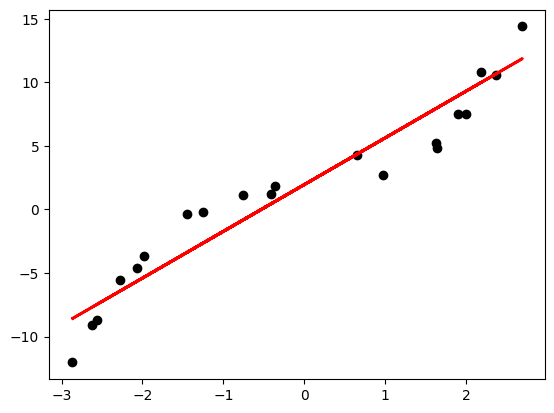

In [87]:
plt.scatter(X_4_test, y_4_test, color='black', label='Dane testowe')
plt.plot(X_4_test, y_4_pred, color='red', linewidth=2, label='Predykcja modelu')

In [88]:
#teraz trenujemy R. wielomianowa

In [89]:
model_poly = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=3),
    LinearRegression()
)
#degre 3 bo mamy x^3

In [108]:
model_poly.fit(X_4_train, y_4_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('polynomialfeatures', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",3
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [109]:
y_4_test_pred = model_poly.predict(X_4_test)
y_4_test_pred


array([[ -9.25952517],
       [ 10.99313157],
       [  5.74660615],
       [  3.30782411],
       [ -1.07578034],
       [  1.39904692],
       [ -0.36762375],
       [  9.31971033],
       [-12.27802432],
       [  0.8273852 ],
       [  1.33909264],
       [  2.61611386],
       [  7.23774143],
       [ 14.43801409],
       [ -6.06381854],
       [ -4.3882814 ],
       [  5.71693056],
       [ -8.60042998],
       [  7.92385226],
       [ -3.80089548]])

In [110]:
residuals_poly = y_4_test - y_4_test_pred 
residuals_poly

array([[ 0.18764845],
       [-0.37964548],
       [-0.92347151],
       [-0.59658   ],
       [ 0.74540938],
       [ 0.45995533],
       [ 0.15472612],
       [ 1.52181854],
       [ 0.23349614],
       [ 0.27621895],
       [-0.09515014],
       [ 1.67244004],
       [ 0.28310553],
       [-0.03569656],
       [ 0.49385242],
       [-0.24704869],
       [-0.47741778],
       [-0.11622179],
       [-0.38498391],
       [ 0.10097009]])

In [111]:
y_4_test

array([[ -9.07187672],
       [ 10.6134861 ],
       [  4.82313463],
       [  2.71124411],
       [ -0.33037096],
       [  1.85900225],
       [ -0.21289763],
       [ 10.84152888],
       [-12.04452818],
       [  1.10360414],
       [  1.24394249],
       [  4.2885539 ],
       [  7.52084697],
       [ 14.40231753],
       [ -5.56996612],
       [ -4.63533009],
       [  5.23951278],
       [ -8.71665177],
       [  7.53886835],
       [ -3.69992539]])

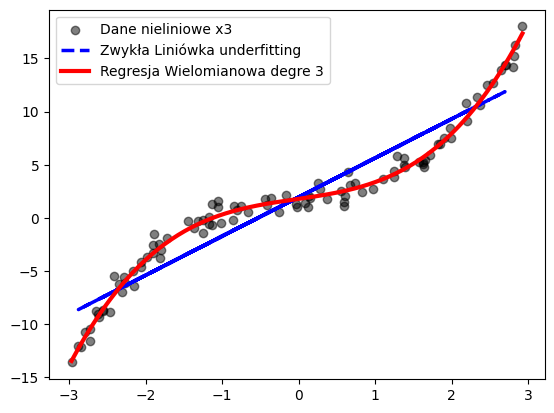

In [112]:
#xplot ladnie laczy punkty od najmniejszej do najwiekszej
X_plot = np.linspace(X_4.min(), X_4.max(), 200).reshape(-1, 1)
y_plot_pred = model_poly.predict(X_plot)

plt.scatter(X_4, y_4, color='black', alpha=0.5, label='Dane nieliniowe x3')
plt.plot(X_4_test, y_4_pred, color='blue', linewidth=2.5, linestyle='--', label='Zwykła Liniówka underfitting')
plt.plot(X_plot, y_plot_pred, color='red', linewidth=3, label='Regresja Wielomianowa degre 3')
plt.legend()

Zadanie 4 — Bias-variance na różnych stopniach wielomianu
 Napisz funkcję bias_variance_experiment(X, y, degrees), która dla różnych stopni regresji wielomianowej (np. 1, 3, 10) liczy błąd na zbiorze treningowym i testowym, a wynik przedstawia na wykresie — tak by pokazać underfitting i overfitting.

In [158]:
def bias_variance_experiment(X, y, degrees):

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    plt.figure(figsize=(16, 5))

    train_errors = []
    test_errors = []

    for i, d in enumerate(degrees):
        model_poly = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=d),
        LinearRegression()
        )

        model_poly.fit(X_train,y_train)
        y_pred_test = model_poly.predict(X_test)
        y_pred_train = model_poly.predict(X_train)
    
        mse_test = mean_squared_error(y_test, y_pred_test)
        test_errors.append(mse_test)
        mse_train = mean_squared_error(y_train, y_pred_train)
        train_errors.append(mse_train)



        plt.subplot(1, len(degrees), i + 1)

        plt.scatter(X_train, y_train, color="blue", alpha=0.6, label="Train")
        plt.scatter(X_test, y_test, color="green", alpha=0.6, label="Test")
        
        # Generujemy gładką linię (dynamiczny zakres dopasowany do X)
        X_line = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
        y_line = model_poly.predict(X_line)

        plt.plot(X_line, y_line, color="red", linewidth=2, label="Model")


        plt.title(f"Stopień {d}\nTrain MSE: {mse_train:.4f}\nTest MSE: {mse_test:.4f}")
        plt.legend()
    return train_errors, test_errors



([0.22618580859279797,
  0.07923247570539127,
  0.0718387113538049,
  0.0709869974788443,
  0.06743773875167455,
  0.062406592946174164],
 [0.21691027397886048,
  0.05776531507628846,
  0.058533830851389045,
  0.05597990849871041,
  0.07355333099861985,
  0.5440022663961493])

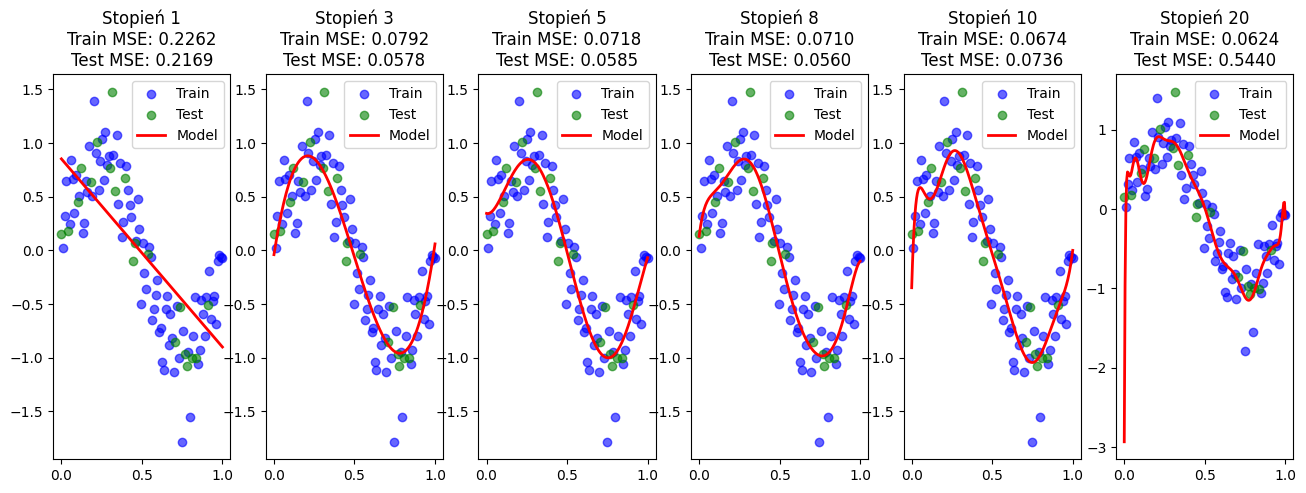

In [165]:
degrees = [1, 3, 5, 8, 10,20]
np.random.seed(42)
X_new = np.linspace(0, 1, 100).reshape(-1, 1)
y_new = np.sin(2 * np.pi * X_new).ravel() + np.random.normal(0, 0.3, 100)
bias_variance_experiment(X_new, y_new, degrees)


#under fiting - błąd treningowy - wysoki testowy -  wysoki 

#sweet spot  treningowy - niski testowy - niski

#overfiting treningowy - b niski testowy - wysoki

test